Josh Lee
George Rodriguez

Lab 4:
Dataset URL: https://www.kaggle.com/datasets/neuromusic/avocado-prices



In [ ]:
import numpy as np                          # For numerical operations
import pandas as pd                         # For loading and managing the dataset
import matplotlib.pyplot as plt             # For plotting the PCA scatter chart

from sklearn.preprocessing import StandardScaler   # For normalizing feature values
from sklearn.decomposition import PCA              # For reducing dimensions via PCA

print('imported all libraries')

imported all libraries


In [ ]:
#import and upload commands:
from google.colab import files
uploaded = files.upload()

Saving avocado.csv to avocado.csv


In [ ]:
#set variable df into the panda readable csv file
df = pd.read_csv('avocado.csv')
print('Dataset shape:', df.shape) #printline for the datasets shape (r,c)

df.head() #displays first 5 rows

Dataset shape: (18249, 14)


,Unnamed: 0,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
0,0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany
1,1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany
2,2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany
3,3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany
4,4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany


In [ ]:
#identifies features loop + print line showcasing quantity of columns present
features = [col for col in df.columns if col != 'avocado_type']
print('number of features: ', len(features))
#output: 14; meaning there are 14 different columns in our dataset

print('Feature names:', features)
#output: an array of our column names

print('Label Distribution (type):')
print(df['type'].value_counts().sort_index())
#output: cultivar 1 (conventional avocados): 9126  | cultivar 2 (organic avocados): 9123

number of features:  14
Feature names: ['Unnamed: 0', 'Date', 'AveragePrice', 'Total Volume', '4046', '4225', '4770', 'Total Bags', 'Small Bags', 'Large Bags', 'XLarge Bags', 'type', 'year', 'region']
Label Distribution (type):
type
conventional    9126
organic         9123
Name: count, dtype: int64


In [ ]:
#We had to create a new array with our dataset due to different string/integer values causing issues.  We only added the columns that included integers.
numerical_features = ['AveragePrice', 'Total Volume', '4046', '4225', '4770', 'Total Bags', 'Small Bags', 'Large Bags', 'XLarge Bags', 'year'] #created a variable that only groups the columns with integers
raw_features = df[numerical_features] #created a new variable that = the dataframe column variables we listed above

#Algorithm to determine the mean and std:
x = StandardScaler().fit_transform(raw_features) # result of X is the numpy array with each feature having the mean = 0 and std = 1
print('Normalized data stats:')
print('  Mean : {:.6f}  (should be ~0)'.format(np.mean(x)))
print('  Std  : {:.6f}  (should be ~1)'.format(np.std(x)))
print('  Shape:', x.shape) #output: shape is changed due to us creating new measurable variable columns

Normalized data stats:
  Mean : -0.000000  (should be ~0)
  Std  : 1.000000  (should be ~1)
  Shape: (18249, 10)


In [ ]:
#PCA Algorithm:
pca = PCA(n_components=2) #creation of PCA variable; setting the dimensions we want to only 2

principal_components = pca.fit_transform(x) #creating principal component variable, setting it equal to pca.fit_transform function(x) (x being the variable created above ^)

print('PCA output shape:', principal_components.shape) #output: prints out the rows based on the 2 dimensions we set; change n_components & columns array below if we want to add or remove any

pca_df = pd.DataFrame(principal_components, columns=['PC1', 'PC2']) #new PCA Dataframe that only includes our principal_compents and columns we made
print(pca_df.head())


PCA output shape: (18249, 2)
        PC1       PC2
0 -0.615687 -1.091611
1 -0.623047 -1.061570
2 -0.512720 -1.685514
3 -0.560549 -1.462493
4 -0.612178 -1.165508


In [ ]:
#explaining the variance ratios
pc1_var, pc2_var = pca.explained_variance_ratio_ #function for the pc variances into the pca.explained variance ratio funciton

#printlines that puts the data into words:
print('Explained variance per principal component:')
print('  PC1 : {:.1%}  — direction of greatest spread in the data'.format(pc1_var))
print('  PC2 : {:.1%}  — direction of second greatest spread'.format(pc2_var))
print('  ──────────────────────────────────────────────')
print('  Total: {:.1%}  of original information retained in 2D'.format(pc1_var + pc2_var))
print('  ──────────────────────────────────────────────')
print('Explained variation per principal component: {}'.format(pca.explained_variance_ratio_))

Explained variance per principal component:
  PC1 : 70.3%  — direction of greatest spread in the data
  PC2 : 11.0%  — direction of second greatest spread
  ──────────────────────────────────────────────
  Total: 81.4%  of original information retained in 2D
  ──────────────────────────────────────────────
Explained variation per principal component: [0.70344071 0.11027446]


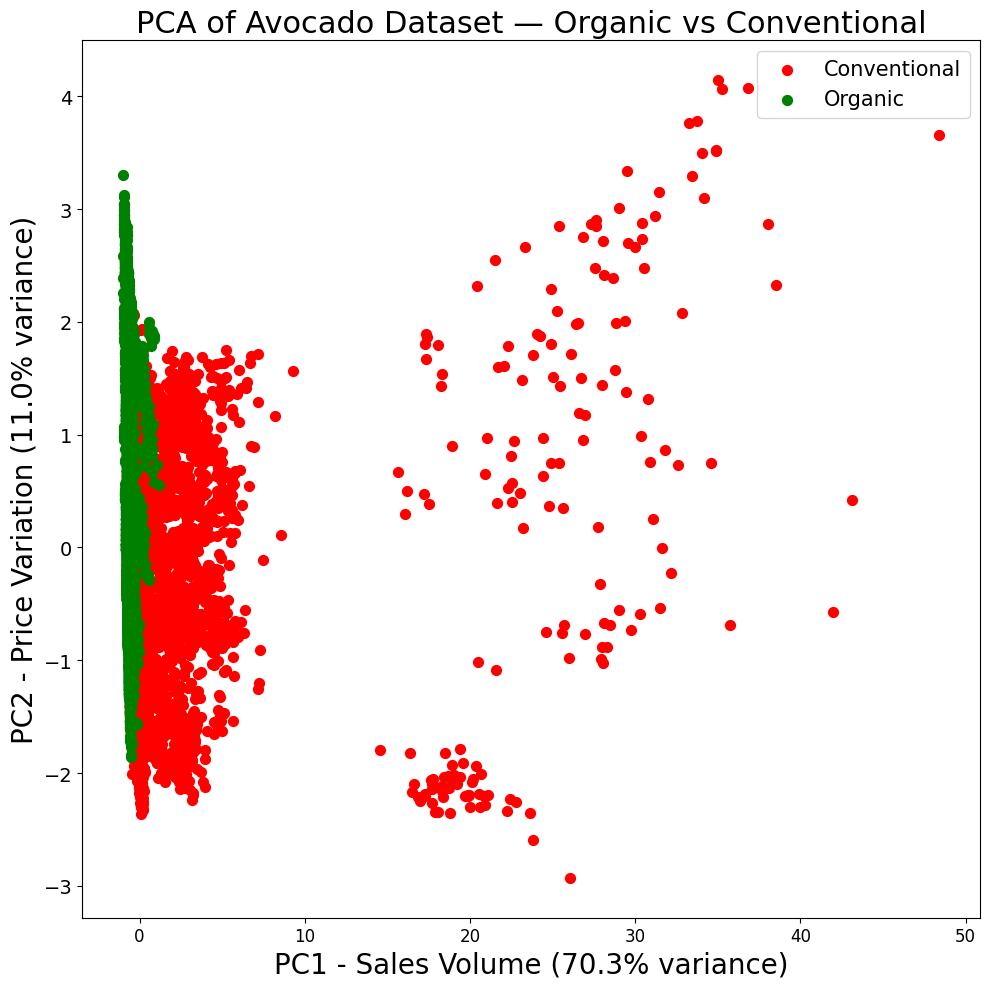

Plot saved as pca_avocado.png


In [ ]:
# Set up the figure canvas (10x10 inches for a clear, large plot)
plt.figure(figsize=(10, 10))

# Axis labels and title
plt.xlabel('PC1 - Sales Volume ({:.1%} variance)'.format(pc1_var), fontsize=20)
plt.ylabel('PC2 - Price Variation ({:.1%} variance)'.format(pc2_var), fontsize=20)
plt.title('PCA of Avocado Dataset — Organic vs Conventional', fontsize=22)
plt.xticks(fontsize=12)
plt.yticks(fontsize=14)

# One color + name per avocado type
colors = {
    'conventional': ('r', 'Conventional'),
    'organic': ('g', 'Organic')
}

for label, (color, name) in colors.items():
    mask = (df['type'] == label)

    plt.scatter(
        pca_df.loc[mask, 'PC1'],
        pca_df.loc[mask, 'PC2'],
        c=color,
        s=50,
        label=name
    )

# Add legend, tighten layout, and display
plt.legend(prop={'size': 15})
plt.tight_layout()
plt.savefig('pca_avocado.png', dpi=150)
plt.show()

print('Plot saved as pca_avocado.png')

#**General Audience Write-Up**

This program explores an avocado sales dataset and uses a method called Principal Component Analysis (PCA) to simplify many numerical measurements into a 2-D view that can be easily visualized. After loading the data, it checks the dataset’s size, lists the available columns, and reports how many entries are “organic” versus “conventional” to confirm the groups are reasonably balanced. Because the dataset contains a mix of text and numbers, the code focuses only on the numeric columns (such as average price, total volume, and bag counts). Next, it “standardizes” the numeric values so that columns measured on different scales (for example, price versus volume) are put on equal footing. PCA is then ran to create two new combined measures (PC1 and PC2) that capture the largest overall patterns in the numeric data. The code prints how much of the dataset’s original variation is preserved by these two components, which indicates how much information is retained after compressing the data.

Finally, the program plots each record as a point on a scatterplot using PC1 and PC2, coloring points by avocado type (organic vs. conventional). If the colors cluster into separate regions, it suggests the two types differ in meaningful ways across price and sales/volume behavior; if they overlap heavily, it suggests the numeric patterns are generally similar. The plot is displayed and also saved as “pca_avocado.png” for inclusion in a potential report or presentation.